# Keypoint Counting Classifiers (KCC)

This notebook demonstrates the setup for **Keypoint Counting Classifiers (KCC)**, a method for few-shot image classification that counts how many learned visual keypoints appear in a query image.

KCC uses [DINOv2](https://github.com/facebookresearch/dinov2) as a backbone for extracting rich visual features from images.

**Reference:**
> Wickstrøm, K., et al. *Keypoint Counting Classifiers*. arXiv:2512.17891, 2024. https://arxiv.org/abs/2512.17891

## 1. Install Dependencies

In [335]:
!pip install torch torchvision transformers Pillow requests matplotlib --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: D:\python-310\python.exe -m pip install --upgrade pip


## 2. Load Example Bird Images from Wikimedia Commons

We load a small set of bird images freely available from [Wikimedia Commons](https://commons.wikimedia.org/).

In [336]:
import os
import requests
import time
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Bird images from Wikimedia Commons (CC-licensed)

BIRD_IMAGES = {
    "query_image": "https://upload.wikimedia.org/wikipedia/commons/7/73/Atlantic_puffin_elliston_7.24.22_DSC_0747.jpg",
    "Atlantic Puffin": "https://commons.wikimedia.org/wiki/Special:FilePath/Atlantic%20Puffin.jpg",
    "European Robin": "https://commons.wikimedia.org/wiki/Special:FilePath/European%20Robin.jpg",
    "Blue Tit": "https://commons.wikimedia.org/wiki/Special:FilePath/Eurasian%20blue%20tit%20Lancashire.jpg",
}

def load_image_from_url(url: str) -> Image.Image:
    """Download an image from a URL and return a PIL Image."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

def load_or_cache_image(name: str, url: str, cache_dir="bird_cache") -> Image.Image:
    os.makedirs(cache_dir, exist_ok=True)
    path = os.path.join(cache_dir, f"{name}.jpg")

    if os.path.exists(path):
        return Image.open(path).convert("RGB")

    headers = {"User-Agent": "Mozilla/5.0", "Accept": "image/*,*/*;q=0.8"}
    r = requests.get(url, headers=headers, timeout=15)
    r.raise_for_status()

    img = Image.open(BytesIO(r.content)).convert("RGB")
    img.save(path)
    return img


images = {name: load_or_cache_image(name, url) for name, url in BIRD_IMAGES.items()}
print(f"Loaded {len(images)} bird images.")


Loaded 4 bird images.


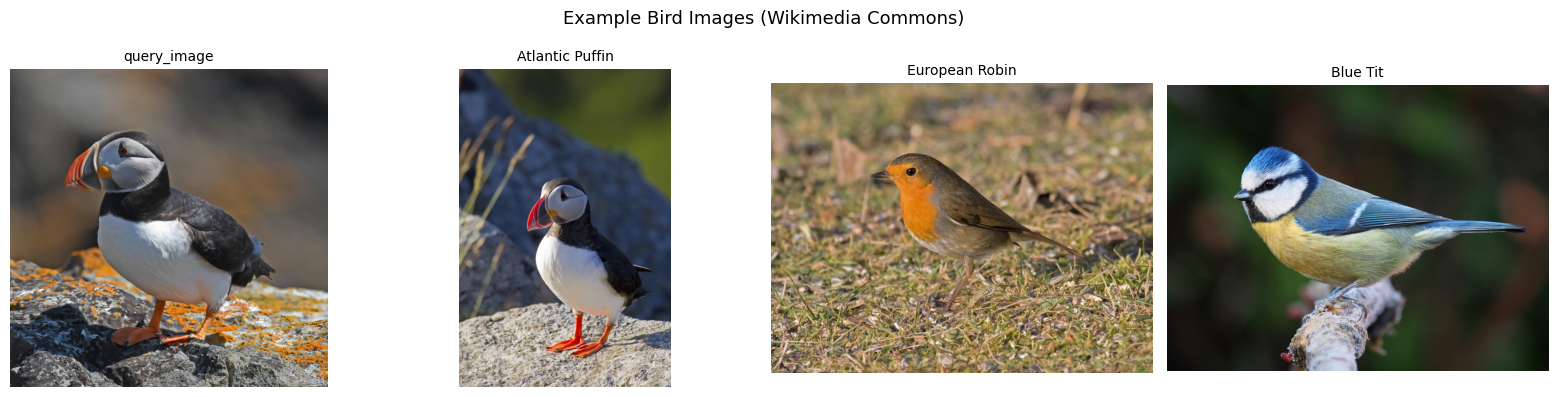

In [337]:
fig, axes = plt.subplots(1, len(images), figsize=(16, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.suptitle("Example Bird Images (Wikimedia Commons)", fontsize=13)
plt.tight_layout()
plt.show()

Resize images to a fixed size

To ensure a fair visual comparison and a consistent input size for later patch-based analysis, all images are resized to the same spatial resolution.

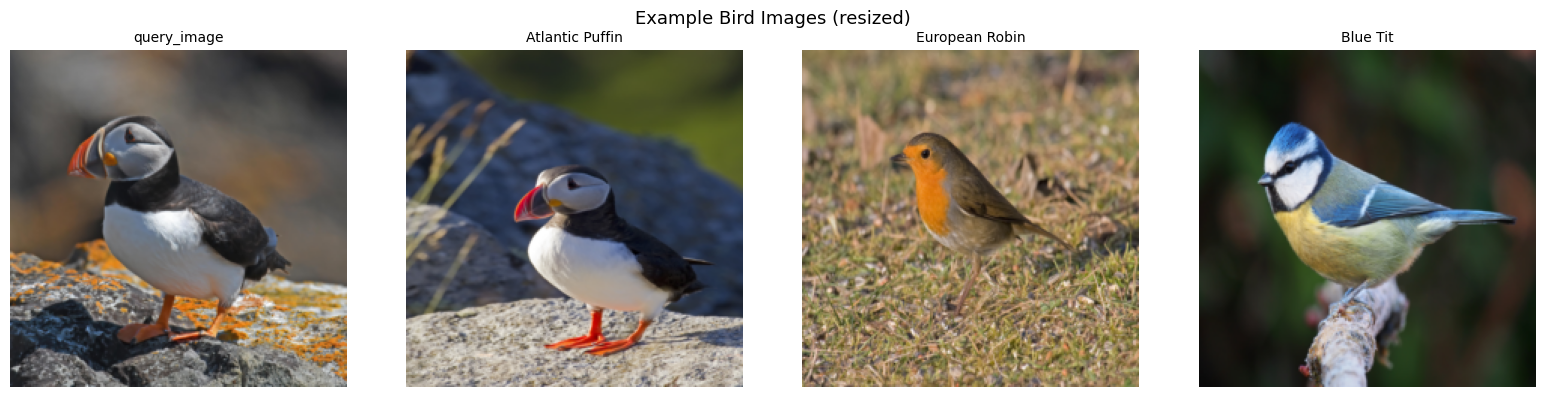

In [338]:
from PIL import Image
import matplotlib.pyplot as plt

TARGET_SIZE = (224, 224)

images_resized = {}
for name, img in images.items():
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    images_resized[name] = img.convert("RGB").resize(TARGET_SIZE, Image.BILINEAR)

fig, axes = plt.subplots(1, len(images_resized), figsize=(16, 4))
for ax, (name, img) in zip(axes, images_resized.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.suptitle("Example Bird Images (resized)", fontsize=13)
plt.tight_layout()
plt.show()

images = images_resized

## 3. Set Up DINOv2 Feature Extraction

[DINOv2](https://github.com/facebookresearch/dinov2) (Oquab et al., 2023) provides powerful self-supervised visual features that serve as the backbone for KCC.
We use the `facebook/dinov2-base` checkpoint from Hugging Face.

In [339]:
import torch
from transformers import AutoImageProcessor, AutoModel

DINOV2_MODEL = "facebook/dinov2-base"

processor = AutoImageProcessor.from_pretrained(DINOV2_MODEL)
model = AutoModel.from_pretrained(DINOV2_MODEL)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"DINOv2 model loaded on {device}.")
print(f"Model hidden size: {model.config.hidden_size}")

DINOv2 model loaded on cuda.
Model hidden size: 768


In [340]:
print(processor)
print("size:", processor.size)
print("crop_size:", getattr(processor, "crop_size", None))
print("do_resize:", getattr(processor, "do_resize", None))
print("do_center_crop:", getattr(processor, "do_center_crop", None))

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

size: {'shortest_edge': 256}
crop_size: {'height': 224, 'width': 224}
do_resize: True
do_center_crop: True


## 4. Extract DINOv2 Features

We extract patch-level features from each bird image. These dense feature maps form the basis for keypoint detection in KCC.

In [341]:
import numpy as np


def extract_features(image: Image.Image) -> torch.Tensor:
    """Extract patch-level DINOv2 features from a PIL image.

    Returns a tensor of shape (num_patches, hidden_size).
    """
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # last_hidden_state: (1, num_patches + 1, hidden_size)
    # Index 0 is the [CLS] token; remaining tokens are patch features
    patch_features = outputs.last_hidden_state[0, 1:, :]
    return patch_features.cpu()


features = {name: extract_features(img) for name, img in images.items()}

for name, feat in features.items():
    print(f"{name}: feature shape = {feat.shape}")

query_image: feature shape = torch.Size([256, 768])
Atlantic Puffin: feature shape = torch.Size([256, 768])
European Robin: feature shape = torch.Size([256, 768])
Blue Tit: feature shape = torch.Size([256, 768])


## 5. Visualise Patch Features with PCA

We use PCA to project the high-dimensional patch features to 3 dimensions and visualise them as an RGB overlay on each image.

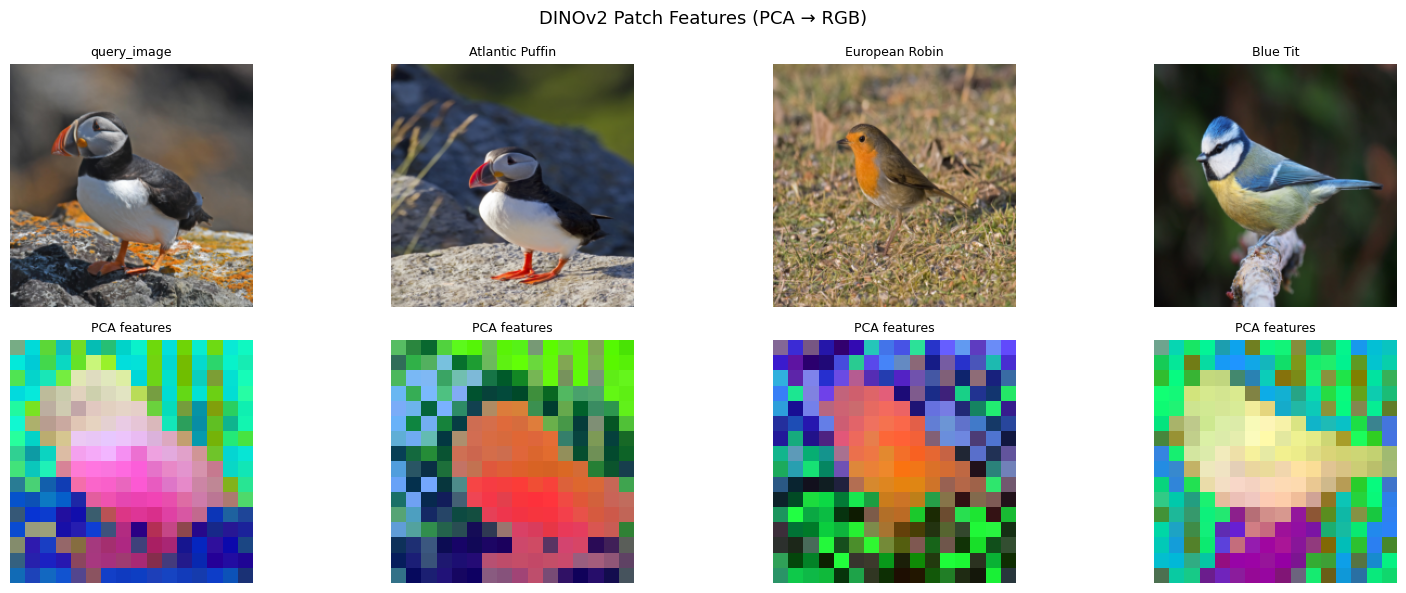

In [342]:
from sklearn.decomposition import PCA

# Install scikit-learn if needed
try:
    import sklearn  # noqa: F401
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "--quiet"])
    from sklearn.decomposition import PCA  # noqa: F811

patch_size = 14  # DINOv2-base uses 14×14 patches

fig, axes = plt.subplots(2, len(images), figsize=(16, 6))
for col, (name, feat) in enumerate(features.items()):
    feat_np = feat.numpy()  # (num_patches, hidden_size)

    # Fit PCA to 3 components for RGB visualisation
    pca = PCA(n_components=3)
    pca_feat = pca.fit_transform(feat_np)  # (num_patches, 3)

    # Normalise each channel to [0, 1]
    for c in range(3):
        pca_feat[:, c] = (pca_feat[:, c] - pca_feat[:, c].min()) / (
            pca_feat[:, c].max() - pca_feat[:, c].min() + 1e-8
        )

    n_patches = feat_np.shape[0]
    grid_size = int(np.sqrt(n_patches))
    pca_map = pca_feat.reshape(grid_size, grid_size, 3)

    axes[0, col].imshow(images[name])
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(pca_map)
    axes[1, col].set_title("PCA features", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("DINOv2 Patch Features (PCA → RGB)", fontsize=13)
plt.tight_layout()
plt.show()

In [346]:
# Normalize the visual features
import numpy as np
from sklearn.cluster import KMeans

def normalize_rows(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """L2-normalize each row vector."""
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

normalized_features = {
    name: normalize_rows(feat.numpy())
    for name, feat in features.items()
}

for name, feat in normalized_features.items():
    norms = np.linalg.norm(feat, axis=1)
    print(f"{name}: shape = {feat.shape}")

def get_foreground_mask_from_features(
    feat: np.ndarray,
    n_clusters: int = 2,
    border_width: int = 1,
    random_state: int = 0
):
    feat = normalize_rows(feat)

    n_patches = feat.shape[0]
    grid_size = int(np.sqrt(n_patches))
    assert grid_size * grid_size == n_patches

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(feat)
    label_map = labels.reshape(grid_size, grid_size)

    border_labels = np.concatenate([
        label_map[0, :],
        label_map[-1, :],
        label_map[:, 0],
        label_map[:, -1]
    ])
    bg_label = np.bincount(border_labels).argmax()
    fg_mask = labels != bg_label

    return fg_mask, label_map, bg_label

query_image: shape = (256, 768)
Atlantic Puffin: shape = (256, 768)
European Robin: shape = (256, 768)
Blue Tit: shape = (256, 768)


## Next Steps

With per-patch DINOv2 features in hand, the KCC pipeline continues by:

1. **Learning keypoints** – clustering or optimising patch-level features to identify distinctive visual parts.
2. **Counting keypoint activations** – for a query image, counting how many of the learned keypoints are present.
3. **Classification** – using keypoint counts as a lightweight, interpretable feature vector for a few-shot classifier.

See the paper for full details: https://arxiv.org/abs/2512.17891

## 6. Learning keypoints with best buddies and clustering

1. Treat the first bird image as a **query** and the remaining images as **prototypes**.
2. Find **best-buddy patch pairs**: a query patch and a prototype patch are paired if they are mutual nearest neighbours in feature space.
3. Remove many background patches using a  **PCA-based foreground heuristic**.
4. Cluster the remaining best-buddy pairs to obtain a small set of representative **learned keypoints**.
5. Visualise the learned correspondences and build a **count vector** for each image.

This is a demonstration notebook, but it shows the core intuition behind KCC: learning a small set of semantically meaningful patch-level parts.


In [ ]:
from typing import Dict, List, Tuple
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np
import matplotlib.pyplot as plt


query_name = list(images.keys())[0]
prototype_names = list(images.keys())[1:]

query_feat = features[query_name].numpy()
prototype_feats = [features[name].numpy() for name in prototype_names]
all_prototype_feat = np.concatenate(prototype_feats, axis=0)

num_query_patches = query_feat.shape[0]
grid_size = int(np.sqrt(num_query_patches))
patch_size = 14

assert grid_size * grid_size == num_query_patches, "Patch count is expected to form a square grid."


def normalize_rows(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)


def patch_index_to_center(idx: int, grid_size: int, image_size: Tuple[int, int]) -> Tuple[float, float]:
    """Return (x, y) patch-centre coordinates in the original image."""
    width, height = image_size
    cell_w = width / grid_size
    cell_h = height / grid_size
    row = idx // grid_size
    col = idx % grid_size
    x = (col + 0.5) * cell_w
    y = (row + 0.5) * cell_h
    return x, y


def build_foreground_masks(
    query_feat: np.ndarray,
    prototype_feats: List[np.ndarray],
    threshold_std: float = 0.2,
    pca_component: int = 0,
) -> Tuple[np.ndarray, Dict[str, np.ndarray], np.ndarray]:
    """
    Build foreground masks per image using PCA projection.
    For each image separately, keep patches whose selected PCA component
    is above that image's mean + threshold_std * std.
    """
    stacked = np.concatenate([query_feat] + prototype_feats, axis=0)
    pca = PCA(n_components=3, random_state=0)
    projected = pca.fit_transform(stacked)

    query_len = len(query_feat)
    query_proj = projected[:query_len]

    query_comp = query_proj[:, pca_component]
    query_threshold = query_comp.mean() + threshold_std * query_comp.std()
    query_mask = query_comp > query_threshold

    proto_masks = {}
    start = query_len
    for name, feat in zip(prototype_names, prototype_feats):
        end = start + len(feat)
        proto_proj = projected[start:end]
        proto_comp = proto_proj[:, pca_component]
        proto_threshold = proto_comp.mean() + threshold_std * proto_comp.std()
        proto_masks[name] = proto_comp > proto_threshold
        start = end

    return query_mask, proto_masks, projected


def decode_prototype_index(global_idx: int, prototype_names: List[str], prototype_feats: List[np.ndarray]) -> Tuple[str, int]:
    start = 0
    for name, feat in zip(prototype_names, prototype_feats):
        end = start + len(feat)
        if start <= global_idx < end:
            return name, global_idx - start
        start = end
    raise IndexError(f"Prototype index {global_idx} is out of range.")


def mutual_nearest_neighbours(
    query_feat: np.ndarray,
    all_prototype_feat: np.ndarray,
    query_fg_mask: np.ndarray,
    prototype_fg_masks: Dict[str, np.ndarray],
) -> List[Dict]:
    """
    Find best-buddy pairs between query patches and all prototype patches.
    """
    nn_query_to_proto, _ = pairwise_distances_argmin_min(query_feat, all_prototype_feat, metric="euclidean")
    nn_proto_to_query, _ = pairwise_distances_argmin_min(all_prototype_feat, query_feat, metric="euclidean")

    pairs = []
    for q_idx, p_global_idx in enumerate(nn_query_to_proto):
        if nn_proto_to_query[p_global_idx] != q_idx:
            continue
        proto_name, p_local_idx = decode_prototype_index(p_global_idx, prototype_names, prototype_feats)
        if not query_fg_mask[q_idx]:
            continue
        if not prototype_fg_masks[proto_name][p_local_idx]:
            continue

        pairs.append(
            {
                "query_idx": int(q_idx),
                "prototype_name": proto_name,
                "prototype_global_idx": int(p_global_idx),
                "prototype_local_idx": int(p_local_idx),
            }
        )
    return pairs


query_fg_mask, prototype_fg_masks, pca_projected = build_foreground_masks(query_feat, prototype_feats)

pairs = mutual_nearest_neighbours(
    query_feat=query_feat,
    all_prototype_feat=all_prototype_feat,
    query_fg_mask=query_fg_mask,
    prototype_fg_masks=prototype_fg_masks,
)

print(f"Query image: {query_name}")
print(f"Number of query patches: {num_query_patches} ({grid_size}x{grid_size})")
print(f"Foreground query patches: {query_fg_mask.sum()} / {len(query_fg_mask)}")
for name in prototype_names:
    print(f"Foreground patches in {name}: {prototype_fg_masks[name].sum()} / {len(prototype_fg_masks[name])}")
print(f"Mutual nearest-neighbour pairs after foreground filtering: {len(pairs)}")

if len(pairs) == 0:
    raise RuntimeError("No best-buddy pairs found. Try relaxing the foreground threshold.")

# Cluster best-buddy pairs to get a learned keypoint set
num_keypoints = min(5, len(pairs))

pair_features = []
for pair in pairs:
    q = query_feat[pair["query_idx"]]
    p = all_prototype_feat[pair["prototype_global_idx"]]
    pair_features.append(np.concatenate([q, p], axis=0))
pair_features = normalize_rows(np.stack(pair_features, axis=0))

kmeans = KMeans(n_clusters=num_keypoints, random_state=0, n_init=10)
kmeans.fit(pair_features)

distances_to_centres = kmeans.transform(pair_features)
representative_pair_indices = np.argmin(distances_to_centres, axis=0)

learned_keypoints = [pairs[idx] for idx in representative_pair_indices]

print("\nLearned keypoints (representative best-buddy pairs):")
for k, kp in enumerate(learned_keypoints, start=1):
    print(
        f"  K{k}: query patch {kp['query_idx']}  <->  "
        f"{kp['prototype_name']} patch {kp['prototype_local_idx']}"
    )


Query image: query_image
Number of query patches: 256 (16x16)
Foreground query patches: 111 / 256
Foreground patches in Atlantic Puffin: 100 / 256
Foreground patches in European Robin: 74 / 256
Foreground patches in Blue Tit: 82 / 256
Mutual nearest-neighbour pairs after foreground filtering: 53

Learned keypoints (representative best-buddy pairs):
  K1: query patch 83  <->  Atlantic Puffin patch 117
  K2: query patch 150  <->  Atlantic Puffin patch 168
  K3: query patch 123  <->  Atlantic Puffin patch 157
  K4: query patch 37  <->  Atlantic Puffin patch 87
  K5: query patch 218  <->  Atlantic Puffin patch 235


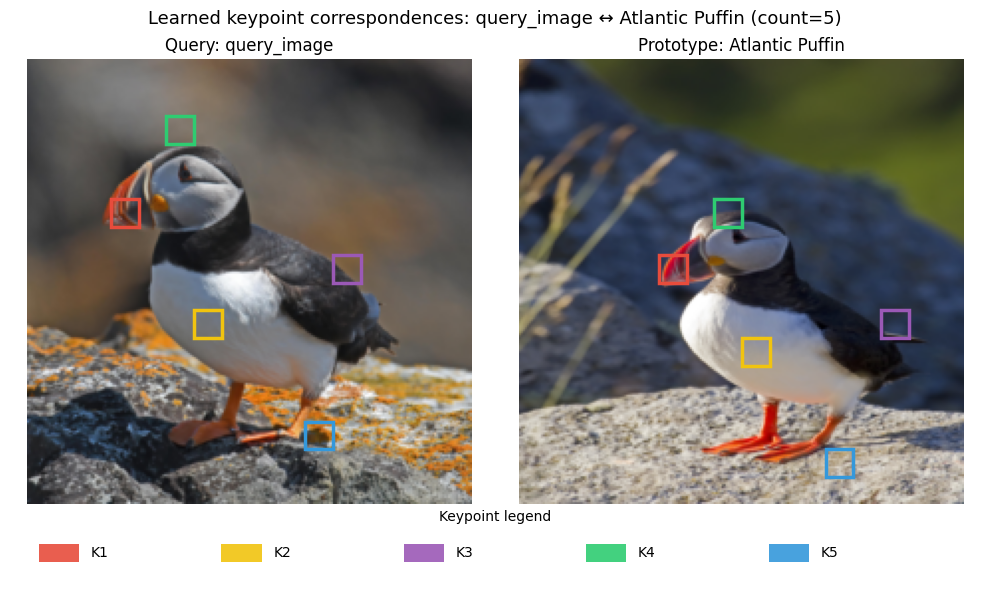

No learned keypoints for prototype: European Robin
No learned keypoints for prototype: Blue Tit
Patch-level counts:


,query,prototype,match_count
0,query_image,Atlantic Puffin,5
1,query_image,Blue Tit,0
2,query_image,European Robin,0


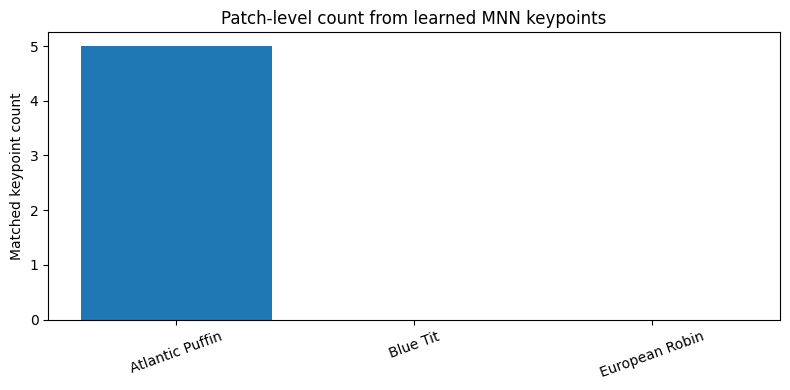

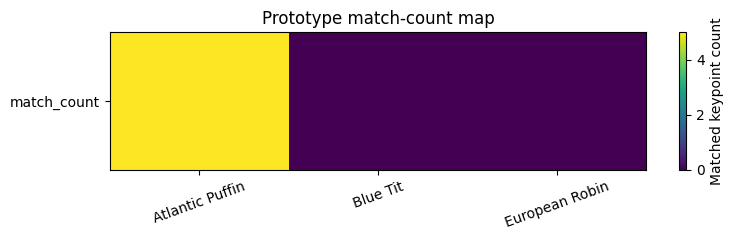

Best matched prototype: Atlantic Puffin
Matched keypoints: 5


In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import List
from PIL import Image

# ============================================================
# 1. Color palette
# ============================================================

KEYPOINT_COLORS = [
    "#e74c3c",  # red
    "#f1c40f",  # yellow
    "#9b59b6",  # purple
    "#2ecc71",  # green
    "#3498db",  # blue
    "#e67e22",  # orange
    "#1abc9c",  # teal
    "#ff66cc",  # pink
]

# ============================================================
# 2. Visualisation helpers
# ============================================================

def draw_keypoints_on_image(ax, image: Image.Image, patch_indices: List[int], labels: List[str], colors: List[str]):
    ax.imshow(image)
    ax.axis("off")

    width, height = image.size
    cell_w = width / grid_size
    cell_h = height / grid_size

    for idx, label, color in zip(patch_indices, labels, colors):
        row = idx // grid_size
        col = idx % grid_size
        x0 = col * cell_w
        y0 = row * cell_h

        rect = Rectangle(
            (x0, y0),
            cell_w,
            cell_h,
            fill=False,
            edgecolor=color,
            linewidth=2.5
        )
        ax.add_patch(rect)
        
def draw_keypoint_legend_row(ax, labels: List[str], colors: List[str]):
    ax.axis("off")

    n_items = len(labels)
    if n_items == 0:
        return

    left_margin = 0.03
    right_margin = 0.03
    usable_width = 1.0 - left_margin - right_margin
    step = usable_width / n_items

    rect_w = min(0.05, step * 0.22)
    rect_h = 0.30
    y = 0.5

    for i, (label, color) in enumerate(zip(labels, colors)):
        x = left_margin + i * step

        ax.add_patch(
            Rectangle(
                (x, y - rect_h / 2),
                rect_w,
                rect_h,
                transform=ax.transAxes,
                facecolor=color,
                edgecolor="none",
                alpha=0.9
            )
        )

        ax.text(
            x + rect_w + 0.012,
            y,
            label,
            transform=ax.transAxes,
            va="center",
            ha="left",
            fontsize=10
        )

# ============================================================
# 3. Group learned keypoints by prototype
# ============================================================

grouped_keypoints = {}
for i, kp in enumerate(learned_keypoints, start=1):
    grouped_keypoints.setdefault(kp["prototype_name"], []).append((f"K{i}", kp))

# ============================================================
# 4. Visualise query <-> prototype correspondences
# ============================================================

prototype_names = [name for name in images.keys() if name != query_name]

for proto_name in prototype_names:
    kp_list = grouped_keypoints.get(proto_name, [])

    if len(kp_list) == 0:
        print(f"No learned keypoints for prototype: {proto_name}")
        continue

    query_indices = [kp["query_idx"] for _, kp in kp_list]
    proto_indices = [kp["prototype_local_idx"] for _, kp in kp_list]
    labels = [label for label, _ in kp_list]
    colors = [KEYPOINT_COLORS[i % len(KEYPOINT_COLORS)] for i in range(len(kp_list))]

    fig = plt.figure(figsize=(10, 6))
    gs = fig.add_gridspec(2, 2, height_ratios=[12, 1.6])

    ax_query = fig.add_subplot(gs[0, 0])
    ax_proto = fig.add_subplot(gs[0, 1])
    ax_legend = fig.add_subplot(gs[1, :])

    draw_keypoints_on_image(
        ax_query,
        images[query_name],
        query_indices,
        labels,
        colors
    )
    ax_query.set_title(f"Query: {query_name}")

    draw_keypoints_on_image(
        ax_proto,
        images[proto_name],
        proto_indices,
        labels,
        colors
    )
    ax_proto.set_title(f"Prototype: {proto_name}")

    draw_keypoint_legend_row(ax_legend, labels, colors)
    ax_legend.set_title("Keypoint legend", fontsize=10, pad=2)

    plt.suptitle(
        f"Learned keypoint correspondences: {query_name} ↔ {proto_name} "
        f"(count={len(kp_list)})",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. Patch-level counting directly from learned MNN keypoints
# ============================================================

prototype_count_rows = []

for proto_name in prototype_names:
    kp_list = grouped_keypoints.get(proto_name, [])
    prototype_count_rows.append({
        "query": query_name,
        "prototype": proto_name,
        "match_count": int(len(kp_list))
    })

prototype_count_df = pd.DataFrame(prototype_count_rows)
prototype_count_df = prototype_count_df.sort_values(
    ["match_count", "prototype"],
    ascending=[False, True]
).reset_index(drop=True)

print("Patch-level counts:")
display(prototype_count_df)

# ============================================================
# 6. Plot patch-level counts
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(prototype_count_df["prototype"], prototype_count_df["match_count"])
plt.ylabel("Matched keypoint count")
plt.title("Patch-level count from learned MNN keypoints")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Optional prototype heatmap
proto_count_matrix = prototype_count_df.set_index("prototype")[["match_count"]].T

plt.figure(figsize=(8, 2.5))
plt.imshow(proto_count_matrix.values, aspect="auto")
plt.yticks([0], ["match_count"])
plt.xticks(range(len(proto_count_matrix.columns)), proto_count_matrix.columns, rotation=20)
plt.colorbar(label="Matched keypoint count")
plt.title("Prototype match-count map")
plt.tight_layout()
plt.show()

# ============================================================
# 7. Final prediction 
# ============================================================

best_row = prototype_count_df.iloc[0]
print("Best matched prototype:", best_row["prototype"])
print("Matched keypoints:", best_row["match_count"])